# RT-DETRv4 파이프라인 (Google Colab)

포함 기능:
1. 환경 설치 및 Drive 마운트
2. 경로 설정 (여기만 수정하면 됨)
3. 공통 유틸 함수
4. 데이터셋 로드 및 카테고리 매핑
5. 클래스 분포 시각화
6. Inpainting 증강 (다수 클래스 알약 제거)
7. Copy-Paste 증강 (단품 알약 이미지 활용)
8. COCO 포맷 변환 및 train/val 분리
9. RT-DETRv4 config 패치
10. 학습 실행
11. Per-class AP 분석
12. Submission CSV 생성


## 1) 환경 설치

In [1]:
!nvidia-smi
!pip install -q --upgrade pip
!pip install -q pyyaml opencv-python-headless tqdm faster-coco-eval albumentations matplotlib pandas

Mon Mar 30 05:33:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2) Google Drive 마운트 + RT-DETRv4 clone

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!git clone https://github.com/RT-DETRs/RT-DETRv4
%cd RT-DETRv4
!git clone https://github.com/facebookresearch/dinov3
!pip install -r requirements.txt

Cloning into 'RT-DETRv4'...
remote: Enumerating objects: 181, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 181 (delta 30), reused 22 (delta 22), pack-reused 127 (from 1)
Receiving objects: 100% (181/181), 5.72 MiB | 13.03 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/RT-DETRv4
Cloning into 'dinov3'...
remote: Enumerating objects: 579, done.
remote: Total 579 (delta 0), reused 0 (delta 0), pack-reused 579 (from 1)
Receiving objects: 100% (579/579), 12.53 MiB | 14.71 MiB/s, done.
Resolving deltas: 100% (204/204), done.


In [4]:
import os, subprocess
from pathlib import Path

RTDETR_REPO = Path("/content/RT-DETRv4")
if not RTDETR_REPO.exists():
    subprocess.run([
        "git", "clone", "--depth", "1",
        "https://github.com/your-fork/RT-DETRv4.git",  # ← 본인 fork URL로 교체
        str(RTDETR_REPO)
    ], check=True)
    print("clone 완료:", RTDETR_REPO)
else:
    print("이미 존재:", RTDETR_REPO)

if str(RTDETR_REPO) not in os.sys.path:
    os.sys.path.insert(0, str(RTDETR_REPO))

이미 존재: /content/RT-DETRv4


## 3) 경로 설정 ← 여기만 수정하면 됩니다

In [6]:
import zipfile
import os

dataset_path = '/content/drive/MyDrive/ai09-level1-project.zip'
output_dir = '/content/ai09-project01/'
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(dataset_path) as zip_file:
    zip_file.extractall(path=output_dir)

data_root = os.path.join(output_dir, 'sprint_ad_project1_data')
train_image_dir = os.path.join(data_root, "train_images")
train_annotation_dir = os.path.join(data_root, "train_annotations")
test_image_dir = os.path.join(data_root, "test_images")

print("Train image dir:", train_image_dir)
print("Train annotation dir:", train_annotation_dir)
print("Test image dir:", test_image_dir)

Train image dir: /content/ai09-project01/sprint_ad_project1_data/train_images
Train annotation dir: /content/ai09-project01/sprint_ad_project1_data/train_annotations
Test image dir: /content/ai09-project01/sprint_ad_project1_data/test_images


In [9]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 54.4 MB/s  0:00:00


In [13]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import fitz  # PyMuPDF
import cv2
import numpy as np
from PIL import Image

# -----------------------------
# 설정 (환경에 맞게 수정)
# -----------------------------
PDF_PATH = "/content/drive/MyDrive/약정보리포트.pdf"
OUT_ROOT = "/content/extracted_single_pills"
PAGE_DPI = 200           # 렌더링 해상도 (dpi). 작으면 빠름, 크면 더 정확
MIN_AREA = 1500          # 컨투어 최소 면적 (픽셀) - 이미지 해상도에 따라 조정
MAX_AREA = 2000000       # 컨투어 최대 면적
CROP_PAD = 0             # 잘라낼 때 여백 픽셀
VERBOSE = True

os.makedirs(OUT_ROOT, exist_ok=True)

# -----------------------------
# 유틸: 이미지 저장
# -----------------------------
def save_bgr_image(img_bgr, out_path, quality=95):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    Image.fromarray(img_rgb).save(out_path, quality=quality)

# -----------------------------
# 페이지 렌더링
# -----------------------------
def render_pdf_page_to_bgr(doc, page_idx, dpi=PAGE_DPI):
    page = doc.load_page(page_idx)
    mat = fitz.Matrix(dpi/72, dpi/72)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    arr = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    if arr.shape[2] == 3:
        img_bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = arr.copy()
    return img_bgr

# -----------------------------
# 후보 영역 검출 (컨투어 기반)
# -----------------------------
def detect_candidate_regions(img_bgr, min_area=MIN_AREA, max_area=MAX_AREA):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    # Otsu threshold (invert so pills (bright) become white if needed)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th_inv = 255 - th
    # morphological close to fill holes
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    th_closed = cv2.morphologyEx(th_inv, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(th_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidates = []
    h, w = img_bgr.shape[:2]
    for cnt in contours:
        x,y,ww,hh = cv2.boundingRect(cnt)
        area = ww*hh
        if area < min_area or area > max_area:
            continue
        # optional aspect ratio filter (너무 길거나 얇은 것 제외)
        ar = ww / float(hh + 1e-6)
        if ar < 0.2 or ar > 5.0:
            continue
        # normalize box to image bounds
        x0 = max(0, x - CROP_PAD); y0 = max(0, y - CROP_PAD)
        x1 = min(w, x + ww + CROP_PAD); y1 = min(h, y + hh + CROP_PAD)
        candidates.append((x0, y0, x1, y1, area))
    # 정렬: 면적 내림차순
    candidates = sorted(candidates, key=lambda x: x[4], reverse=True)
    return candidates

# -----------------------------
# 레이아웃 판단: 페이지에 2개 배치인지 확인
# - 후보가 2개 이상이면 그 두 개 사용
# - 후보가 1개이면 중앙 분할(수평/수직)로 2개 생성
# - 후보가 0개이면 중앙 분할
# -----------------------------
def split_page_into_two(img_bgr, candidates):
    h, w = img_bgr.shape[:2]
    crops = []
    if len(candidates) >= 2:
        # 상위 2개 후보 사용 (면적 기준)
        for i in range(2):
            x0,y0,x1,y1,_ = candidates[i]
            crops.append(img_bgr[y0:y1, x0:x1])
        return crops
    elif len(candidates) == 1:
        # 하나만 검출된 경우: 후보 박스 + 그 박스의 반대편 영역(중앙 분할) 사용
        x0,y0,x1,y1,_ = candidates[0]
        # 판단: 박스가 페이지의 왼쪽/오른쪽/위/아래에 위치하는지 확인
        cx = (x0 + x1) / 2
        cy = (y0 + y1) / 2
        if cx < w * 0.4 or cx > w * 0.6:
            # 좌우로 치우침 -> 수직 분할 (left/right)
            left = img_bgr[:, :w//2]
            right = img_bgr[:, w//2:]
            crops = [left, right]
        else:
            # 중앙 근처 -> 수평 분할 (top/bottom)
            top = img_bgr[:h//2, :]
            bottom = img_bgr[h//2:, :]
            crops = [top, bottom]
        return crops
    else:
        # 후보가 전혀 없으면 중앙 분할 (레이아웃 자동 판단: 가로가 넓으면 좌우, 아니면 상하)
        if w > h:
            left = img_bgr[:, :w//2]
            right = img_bgr[:, w//2:]
            return [left, right]
        else:
            top = img_bgr[:h//2, :]
            bottom = img_bgr[h//2:, :]
            return [top, bottom]

# -----------------------------
# 메인: PDF 한 파일 처리
# -----------------------------
def extract_two_per_page_from_pdf(pdf_path, out_root):
    doc = fitz.open(pdf_path)
    total_saved = 0
    for page_idx in range(len(doc)):
        if VERBOSE:
            print(f"[Page {page_idx+1}/{len(doc)}] rendering...")
        img_bgr = render_pdf_page_to_bgr(doc, page_idx, dpi=PAGE_DPI)
        candidates = detect_candidate_regions(img_bgr)
        if VERBOSE:
            print(f"  detected candidate regions: {len(candidates)}")
        crops = split_page_into_two(img_bgr, candidates)
        # 저장: 페이지 폴더 생성
        page_dir = os.path.join(out_root, f"page_{page_idx+1:03d}")
        os.makedirs(page_dir, exist_ok=True)
        for i, crop in enumerate(crops[:2], start=1):
            out_path = os.path.join(page_dir, f"part_{i}.jpg")
            save_bgr_image(crop, out_path)
            total_saved += 1
        if VERBOSE:
            print(f"  saved {min(2, len(crops))} crops to {page_dir}")
    doc.close()
    return total_saved

# -----------------------------
# 실행
# -----------------------------
if __name__ == "__main__":
    if not os.path.exists(PDF_PATH):
        raise FileNotFoundError(f"PDF not found: {PDF_PATH}")
    print("Start extracting from:", PDF_PATH)
    saved = extract_two_per_page_from_pdf(PDF_PATH, OUT_ROOT)
    print("Done. Total crops saved:", saved)
    print("Output folder:", OUT_ROOT)

Start extracting from: /content/drive/MyDrive/약정보리포트.pdf
[Page 1/28] rendering...
  detected candidate regions: 22
  saved 2 crops to /content/extracted_single_pills/page_001
[Page 2/28] rendering...
  detected candidate regions: 34
  saved 2 crops to /content/extracted_single_pills/page_002
[Page 3/28] rendering...
  detected candidate regions: 21
  saved 2 crops to /content/extracted_single_pills/page_003
[Page 4/28] rendering...
  detected candidate regions: 20
  saved 2 crops to /content/extracted_single_pills/page_004
[Page 5/28] rendering...
  detected candidate regions: 19
  saved 2 crops to /content/extracted_single_pills/page_005
[Page 6/28] rendering...
  detected candidate regions: 24
  saved 2 crops to /content/extracted_single_pills/page_006
[Page 7/28] rendering...
  detected candidate regions: 25
  saved 2 crops to /content/extracted_single_pills/page_007
[Page 8/28] rendering...
  detected candidate regions: 24
  saved 2 crops to /content/extracted_single_pills/page_008

In [8]:
from pathlib import Path

# ══════════════════════════════════════════
#  수정 필요 구역
# ══════════════════════════════════════════

# 데이터셋 루트 (Drive 안 경로)
DATA_ROOT = Path("/content/ai09-project01/sprint_ai_project1_data/")

# 단품 알약 이미지 디렉토리 (annotation 없음)
SINGLE_PILL_DIR = Path("/content/drive/MyDrive/single_pill_images")

# RT-DETRv4 repo
RTDETR_REPO = Path("/content/RT-DETRv4")

# 학습된 체크포인트 (.pth) — 평가/제출 시 사용
BEST_PTH_PATH = Path("/content/drive/MyDrive/rtdetrv4best.pth")

# ══════════════════════════════════════════
#  하이퍼파라미터 (필요 시 조정)
# ══════════════════════════════════════════
SEED              = 42
VAL_RATIO         = 0.2
RESIZE            = 640
TOTAL_BATCH_SIZE  = 2
NUM_WORKERS       = 2
USE_AMP           = True
RESUME_CHECKPOINT = None   # 이어서 학습할 경우 체크포인트 경로 입력

# Inpainting 증강 설정
INPAINT_AUG_RATIO     = 0.5    # 원본 이미지 중 증강할 비율
MAX_AUG_PER_IMAGE     = 1      # 이미지당 최대 inpainting 증강 수
MAJORITY_TOP_PERCENT  = 0.30   # 상위 N% 클래스를 "다수 클래스"로 지정
EXPAND_RATIO          = 0.08   # 마스크 확장 비율
INPAINT_RADIUS        = 7
INPAINT_METHOD        = "telea"  # "telea" or "ns"

# Copy-Paste 증강 설정
COPY_PASTE_PER_IMAGE  = 2      # 이미지당 붙여넣을 단품 알약 수 (최대 4개까지 고려)
COPY_PASTE_RATIO      = 0.4    # 원본 이미지 중 Copy-Paste 증강할 비율
COPY_PASTE_SCALE_RANGE = (0.7, 1.3)  # 붙여넣을 알약 크기 배율 범위

# 제출 설정
CONF_TH  = 0.05
MAX_DET  = 4

# ══════════════════════════════════════════
#  파생 경로 (자동 설정 — 수정 불필요)
# ══════════════════════════════════════════
TRAIN_IMAGE_DIR      = DATA_ROOT / "train_images"
TRAIN_ANNOTATION_DIR = DATA_ROOT / "train_annotations"
TEST_IMAGE_DIR       = DATA_ROOT / "test_images"

BASE_CONFIG      = RTDETR_REPO / "configs" / "rtv4" / "rtv4_hgnetv2_x_coco.yml"
PATCHED_CONFIG   = RTDETR_REPO / "configs" / "rtv4" / "custom_rtdetrv4_config.yml"

OUTPUT_ROOT          = Path("/content/rtdetrv4_work")
AUG_IMAGE_DIR        = OUTPUT_ROOT / "augmented" / "images"
AUG_ANNOTATION_DIR   = OUTPUT_ROOT / "augmented" / "annotations"
COCO_ROOT            = OUTPUT_ROOT / "coco"
COCO_TRAIN_IMG_DIR   = COCO_ROOT / "images" / "train"
COCO_VAL_IMG_DIR     = COCO_ROOT / "images" / "val"
COCO_ANN_DIR         = COCO_ROOT / "annotations"
COCO_TRAIN_JSON      = COCO_ANN_DIR / "instances_train.json"
COCO_VAL_JSON        = COCO_ANN_DIR / "instances_val.json"

# 경로 체크
for name, p in [
    ("TRAIN_IMAGE_DIR",      TRAIN_IMAGE_DIR),
    ("TRAIN_ANNOTATION_DIR", TRAIN_ANNOTATION_DIR),
    ("TEST_IMAGE_DIR",       TEST_IMAGE_DIR),
    ("RTDETR_REPO",          RTDETR_REPO),
    ("BASE_CONFIG",          BASE_CONFIG),
]:
    status = "✅" if p.exists() else "❌ 없음"
    print(f"{status}  {name}: {p}")

print("\nSINGLE_PILL_DIR:", "✅" if SINGLE_PILL_DIR.exists() else "⚠️  없음 (Copy-Paste 증강 스킵됨)")
print("BEST_PTH_PATH:",   "✅" if BEST_PTH_PATH.exists() else "⚠️  없음 (평가/제출 시 필요)")

✅  TRAIN_IMAGE_DIR: /content/ai09-project01/sprint_ai_project1_data/train_images
✅  TRAIN_ANNOTATION_DIR: /content/ai09-project01/sprint_ai_project1_data/train_annotations
✅  TEST_IMAGE_DIR: /content/ai09-project01/sprint_ai_project1_data/test_images
✅  RTDETR_REPO: /content/RT-DETRv4
✅  BASE_CONFIG: /content/RT-DETRv4/configs/rtv4/rtv4_hgnetv2_x_coco.yml

SINGLE_PILL_DIR: ⚠️  없음 (Copy-Paste 증강 스킵됨)
BEST_PTH_PATH: ⚠️  없음 (평가/제출 시 필요)


## 4) 공통 유틸 함수

In [14]:
import os, sys, json, yaml, cv2, shutil, random, math
from copy import deepcopy
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
from tqdm.notebook import tqdm

random.seed(SEED)
np.random.seed(SEED)

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

def find_images(d: Path):
    return sorted([p for p in d.iterdir() if p.suffix.lower() in IMG_EXTS])

def find_jsons(d: Path):
    return sorted(d.rglob("*.json"))

def load_json(p: Path):
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(p: Path, obj):
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def clean_dir(p: Path, wipe=True):
    if wipe and p.exists():
        shutil.rmtree(p)
    p.mkdir(parents=True, exist_ok=True)

def inpaint_flag(name: str):
    return cv2.INPAINT_TELEA if name.lower() == "telea" else cv2.INPAINT_NS

print("유틸 함수 로드 완료")

유틸 함수 로드 완료


## 5) 데이터셋 로드 및 카테고리 매핑

In [15]:
# ── 5-1. 이미지 단위로 annotation json 묶기 ──────────────────────────
def load_records(image_dir: Path, ann_dir: Path):
    """
    각 이미지에 대응하는 모든 annotation json을 모아
    records 리스트로 반환한다.
    record = {
        image_key, image_path, image_file_name,
        json_paths, annotations, data
    }
    """
    grouped = defaultdict(list)
    for jp in tqdm(find_jsons(ann_dir), desc="JSON 스캔"):
        data = load_json(jp)
        imgs = data.get("images", [])
        fname = imgs[0].get("file_name", "") if imgs else ""
        key = Path(fname).stem or jp.stem
        grouped[key].append((jp, data, fname))

    records = []
    for key, items in tqdm(grouped.items(), desc="레코드 생성"):
        rep_jp, rep_data, rep_fname = items[0]

        # 이미지 경로 탐색
        img_path = None
        for fname_try in [rep_fname] + [f"{key}{ext}" for ext in IMG_EXTS]:
            p = image_dir / Path(fname_try).name
            if p.exists():
                img_path = p
                break

        # 모든 annotation 병합
        anns, ann_dicts = [], []
        for jp, data, _ in items:
            for ann in data.get("annotations", []):
                bbox = ann.get("bbox")
                if isinstance(bbox, list) and len(bbox) == 4 and bbox[2] > 0 and bbox[3] > 0:
                    a = deepcopy(ann)
                    a["_src_json"] = str(jp)
                    a["_src_rel"]  = str(jp.relative_to(ann_dir))
                    ann_dicts.append(a)
                    anns.append({"bbox": bbox, "category_id": ann.get("category_id")})

        merged = deepcopy(rep_data)
        merged["annotations"] = ann_dicts
        if not merged.get("images"):
            merged["images"] = [{"file_name": rep_fname}]

        records.append({
            "image_key":       key,
            "image_path":      img_path,
            "image_file_name": Path(rep_fname).name or f"{key}.jpg",
            "json_paths":      [str(jp) for jp, _, _ in items],
            "annotations":     anns,
            "data":            merged,
        })
    return records

records = load_records(TRAIN_IMAGE_DIR, TRAIN_ANNOTATION_DIR)
matched   = [r for r in records if r["image_path"] is not None]
unmatched = [r for r in records if r["image_path"] is None]
ann_counts = [len(r["annotations"]) for r in records]

print(f"총 레코드: {len(records)}개  (이미지 매칭 성공: {len(matched)}, 실패: {len(unmatched)})")
print(f"annotation 수 — min: {min(ann_counts)}, max: {max(ann_counts)}, mean: {sum(ann_counts)/len(ann_counts):.2f}")
if unmatched:
    print("매칭 실패 예시:", [r["image_key"] for r in unmatched[:5]])

JSON 스캔:   0%|          | 0/763 [00:00<?, ?it/s]

레코드 생성:   0%|          | 0/232 [00:00<?, ?it/s]

총 레코드: 232개  (이미지 매칭 성공: 232, 실패: 0)
annotation 수 — min: 2, max: 4, mean: 3.29


In [16]:
# ── 5-2. 카테고리 매핑 ───────────────────────────────────────────────
def build_category_mapping(ann_dir: Path):
    """
    모든 json에서 category 정보를 수집해
    old_id → new_id(0-indexed) 매핑과 master_categories 리스트를 만든다.
    """
    bank = {}
    for jp in tqdm(find_jsons(ann_dir), desc="카테고리 수집"):
        for cat in load_json(jp).get("categories", []):
            oid = cat.get("id")
            if oid is not None and oid not in bank:
                bank[oid] = deepcopy(cat)

    old_ids = sorted(bank)
    old_to_new = {oid: nid for nid, oid in enumerate(old_ids)}
    master = [{"id": old_to_new[oid], "name": bank[oid].get("name", str(oid))} for oid in old_ids]
    return old_to_new, master

OLD_TO_NEW, MASTER_CATS = build_category_mapping(TRAIN_ANNOTATION_DIR)
NUM_CLASSES = len(MASTER_CATS)
ID_TO_NAME  = {c["id"]: c["name"] for c in MASTER_CATS}

print(f"클래스 수: {NUM_CLASSES}")
print("예시 categories:", MASTER_CATS[:5])
assert NUM_CLASSES == 56, f"56개여야 하는데 {NUM_CLASSES}개입니다. 데이터 확인 필요"

카테고리 수집:   0%|          | 0/763 [00:00<?, ?it/s]

클래스 수: 56
예시 categories: [{'id': 0, 'name': '보령부스파정 5mg'}, {'id': 1, 'name': '뮤테란캡슐 100mg'}, {'id': 2, 'name': '일양하이트린정 2mg'}, {'id': 3, 'name': '기넥신에프정(은행엽엑스)(수출용)'}, {'id': 4, 'name': '무코스타정(레바미피드)(비매품)'}]


## 6) 클래스 분포 시각화

/tmp/ipykernel_1645/2177888676.py:41: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1645/2177888676.py:41: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1645/2177888676.py:41: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1645/2177888676.py:41: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1645/2177888676.py:41: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1645/2177888676.py:41: UserWarning: Glyph 47536 (\N{HANGUL SYLLABLE RIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1645/2177888676.py:41: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_la

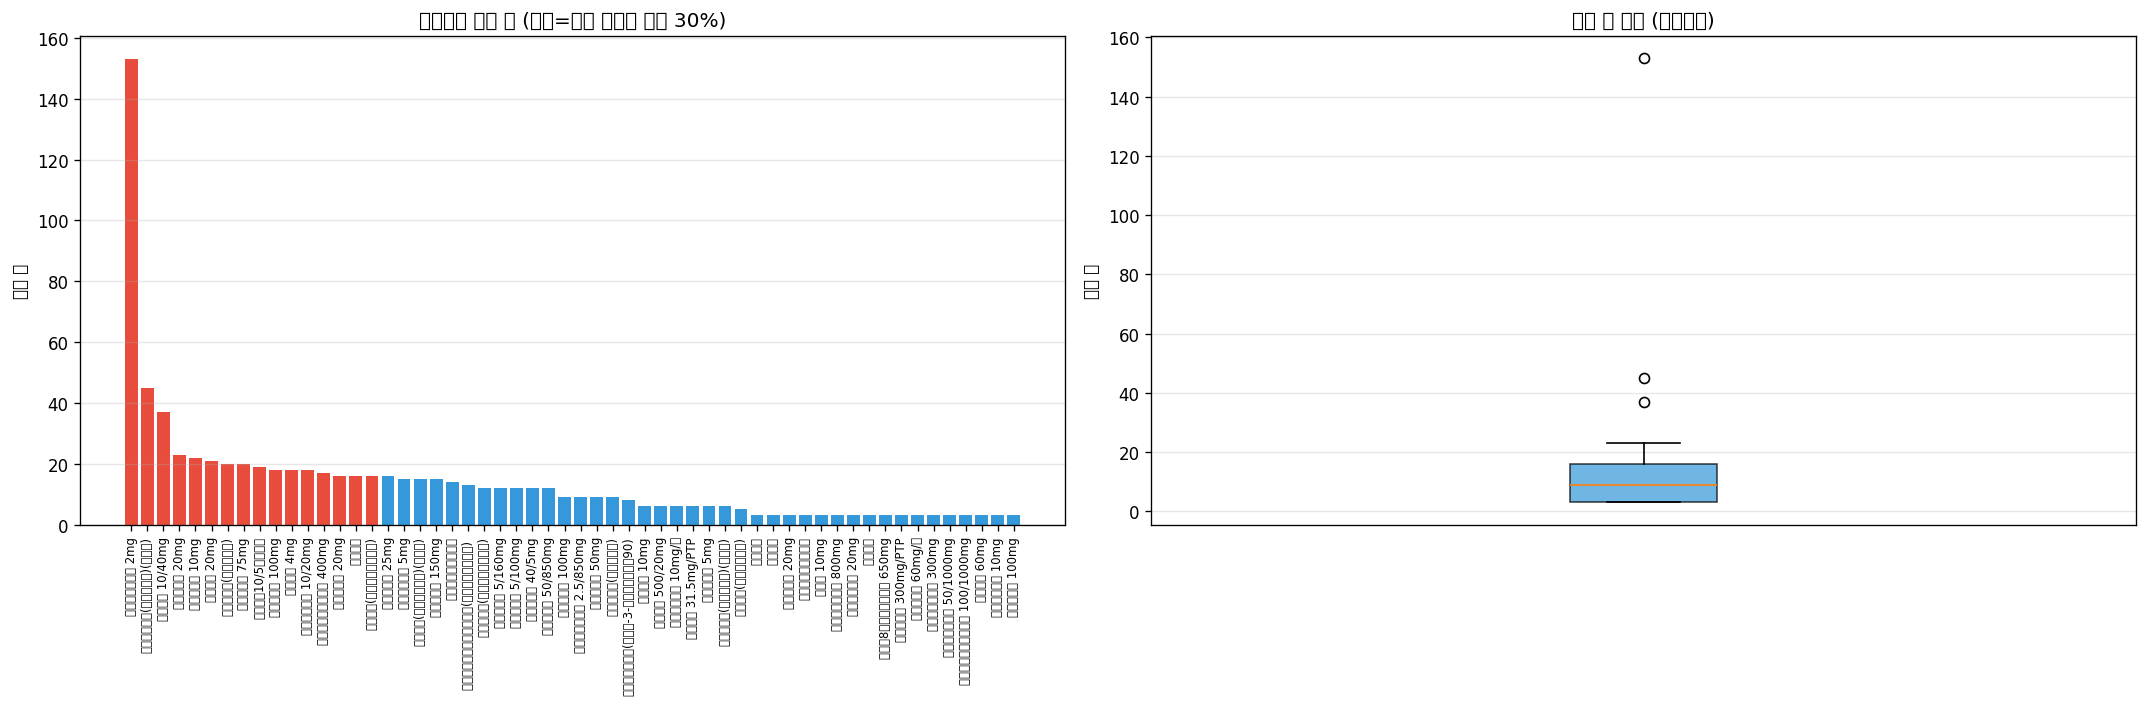


총 annotation 수: 763개
최다 클래스: 일양하이트린정 2mg (153개) / 최소 클래스: 졸로푸트정 100mg (3개)
불균형 비율: 51.0x
Inpainting 대상 다수 클래스 수: 16개
[2, 3, 52, 14, 27, 13, 6, 25, 53, 15, 43, 54, 20, 29, 24, 50, 55, 0, 12, 18, 47, 19, 45, 26, 35, 36, 33, 1, 44, 30, 40, 17, 22, 41, 10, 34, 23, 4, 7, 42, 48, 28, 38, 32, 16, 49, 5, 11, 8, 21, 31, 51, 46, 37, 9, 39]


In [19]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# 클래스별 샘플 수 집계
class_counter = Counter()
for r in records:
    for ann in r["annotations"]:
        cid = ann.get("category_id")
        if cid is not None:
            new_id = OLD_TO_NEW.get(cid, cid)
            class_counter[new_id] += 1

# 다수 클래스 선정 (inpainting 증강 대상)
sorted_cls   = [c for c, _ in class_counter.most_common()]
top_k        = max(1, int(len(sorted_cls) * MAJORITY_TOP_PERCENT))
MAJORITY_CLS = set(sorted_cls[:top_k])

counts_sorted = [(ID_TO_NAME.get(c, str(c)), class_counter[c]) for c in sorted_cls]
names_s, vals_s = zip(*counts_sorted)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 막대 그래프
colors = ["#e74c3c" if sorted_cls[i] in MAJORITY_CLS else "#3498db" for i in range(len(sorted_cls))]
axes[0].bar(range(len(vals_s)), vals_s, color=colors, width=0.8)
axes[0].set_xticks(range(len(names_s)))
axes[0].set_xticklabels(names_s, rotation=90, fontsize=7)
axes[0].set_ylabel("샘플 수")
axes[0].set_title(f"클래스별 샘플 수 (빨강=다수 클래스 상위 {MAJORITY_TOP_PERCENT*100:.0f}%)")
axes[0].grid(axis="y", alpha=0.3)

# 박스플롯
axes[1].boxplot(vals_s, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_ylabel("샘플 수")
axes[1].set_title("샘플 수 분포 (박스플롯)")
axes[1].set_xticks([])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n총 annotation 수: {sum(class_counter.values())}개")
print(f"최다 클래스: {names_s[0]} ({vals_s[0]}개) / 최소 클래스: {names_s[-1]} ({vals_s[-1]}개)")
print(f"불균형 비율: {vals_s[0] / vals_s[-1]:.1f}x")
print(f"Inpainting 대상 다수 클래스 수: {len(MAJORITY_CLS)}개")
print(sorted_cls)

In [28]:
import os, shutil, re
from pathlib import Path
import pandas as pd

# ---------------- 설정 (환경에 맞게 수정) ----------------
OUT_ROOT = "/content/extracted_single_pills"   # 추출된 이미지들이 있는 루트 (하위 폴더 포함)
DEST_DIR = "/content/extracted_sorted_cls"     # 결과 저장 폴더
MAPPING_CSV = os.path.join(DEST_DIR, "mapping_sorted_cls.csv")
COPY = True                                    # True: 복사, False: 이동
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
# -------------------------------------------------------

os.makedirs(DEST_DIR, exist_ok=True)

# 0) sorted_cls 존재 확인 (세션 변수)
try:
    sorted_cls  # noqa: F821
except NameError:
    raise NameError("sorted_cls 변수가 세션에 없습니다. 먼저 sorted_cls를 정의하세요.")

# 1) OUT_ROOT 아래 모든 이미지 파일 재귀 수집 및 정렬
def collect_images(root):
    p = Path(root)
    files = [f for f in p.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXTS]
    # 정렬 기준: 디렉터리 경로 + 파일명 (문자열 정렬)
    files_sorted = sorted(files, key=lambda x: (str(x.parent).lower(), x.name.lower()))
    return files_sorted

all_imgs = collect_images(OUT_ROOT)
n_imgs = len(all_imgs)
print(f"Found {n_imgs} images under {OUT_ROOT}")

# 2) sorted_cls 길이 확인
n_keys = len(sorted_cls)
print(f"sorted_cls length: {n_keys}")

# 3) 매칭 모드 결정
if n_keys == n_imgs:
    mode = "one_to_one"
elif n_keys * 2 == n_imgs:
    mode = "two_per_key"
else:
    mode = "best_effort"
    print("WARNING: 이미지 수와 sorted_cls 길이가 일치하지 않습니다. 가능한 만큼만 매칭합니다.")

# 안전한 키 정규화 (파일명에 안전하게 사용)
def normalize_key(k):
    if k is None:
        return "unknown"
    s = str(k).strip()
    s = s.lower()
    s = re.sub(r'[\\/:"*?<>|]+', '_', s)
    s = re.sub(r'\s+', '_', s)
    return s[:80]

# 4) 매칭 및 파일명 생성
mapping = []
img_idx = 0

if mode == "one_to_one":
    for i, key in enumerate(sorted_cls):
        if img_idx >= n_imgs:
            break
        src = all_imgs[img_idx]
        key_norm = normalize_key(key)
        dst_name = f"{key_norm}.jpg"   # {it}.jpg
        dst_path = os.path.join(DEST_DIR, dst_name)
        # 충돌 방지: 덮어쓰기 대신 인덱스 추가 (드물게 발생)
        if os.path.exists(dst_path):
            base, ext = os.path.splitext(dst_name)
            k = 1
            while True:
                candidate = f"{base}_{k}{ext}"
                candidate_path = os.path.join(DEST_DIR, candidate)
                if not os.path.exists(candidate_path):
                    dst_path = candidate_path
                    break
                k += 1
        try:
            if COPY:
                shutil.copy(str(src), dst_path)
            else:
                shutil.move(str(src), dst_path)
            mapping.append({"key": key, "part": 1, "src": str(src), "dst": dst_path})
        except Exception as e:
            mapping.append({"key": key, "part": 1, "src": str(src), "dst": None, "error": str(e)})
        img_idx += 1

elif mode == "two_per_key":
    for i, key in enumerate(sorted_cls):
        key_norm = normalize_key(key)
        for part in (1, 2):
            if img_idx >= n_imgs:
                break
            src = all_imgs[img_idx]
            if part == 1:
                dst_name = f"{key_norm}.jpg"      # 첫번째는 {it}.jpg
            else:
                dst_name = f"{key_norm}_2.jpg"    # 두번째는 {it}_2.jpg
            dst_path = os.path.join(DEST_DIR, dst_name)
            if os.path.exists(dst_path):
                base, ext = os.path.splitext(dst_name)
                k = 1
                while True:
                    candidate = f"{base}_{k}{ext}"
                    candidate_path = os.path.join(DEST_DIR, candidate)
                    if not os.path.exists(candidate_path):
                        dst_path = candidate_path
                        break
                    k += 1
            try:
                if COPY:
                    shutil.copy(str(src), dst_path)
                else:
                    shutil.move(str(src), dst_path)
                mapping.append({"key": key, "part": part, "src": str(src), "dst": dst_path})
            except Exception as e:
                mapping.append({"key": key, "part": part, "src": str(src), "dst": None, "error": str(e)})
            img_idx += 1

else:  # best_effort
    # 가능한 만큼: for each key assign up to 2 images until images exhausted
    for i, key in enumerate(sorted_cls):
        key_norm = normalize_key(key)
        for part in (1, 2):
            if img_idx >= n_imgs:
                break
            src = all_imgs[img_idx]
            if part == 1:
                dst_name = f"{key_norm}.jpg"
            else:
                dst_name = f"{key_norm}_2.jpg"
            dst_path = os.path.join(DEST_DIR, dst_name)
            if os.path.exists(dst_path):
                base, ext = os.path.splitext(dst_name)
                k = 1
                while True:
                    candidate = f"{base}_{k}{ext}"
                    candidate_path = os.path.join(DEST_DIR, candidate)
                    if not os.path.exists(candidate_path):
                        dst_path = candidate_path
                        break
                    k += 1
            try:
                if COPY:
                    shutil.copy(str(src), dst_path)
                else:
                    shutil.move(str(src), dst_path)
                mapping.append({"key": key, "part": part, "src": str(src), "dst": dst_path})
            except Exception as e:
                mapping.append({"key": key, "part": part, "src": str(src), "dst": None, "error": str(e)})
            img_idx += 1

# 5) 매핑 CSV 저장
df_map = pd.DataFrame(mapping)
df_map.to_csv(MAPPING_CSV, index=False, encoding="utf-8-sig")
print("Mapping saved to:", MAPPING_CSV)

# 6) 요약 출력
print("=== Summary ===")
print("Total images found:", n_imgs)
print("sorted_cls length:", n_keys)
print("Mode:", mode)
print("Pages matched (keys used):", len(set([m['key'] for m in mapping])))
print("Files written to:", DEST_DIR)
if img_idx < n_imgs:
    print(f"Note: {n_imgs - img_idx} images were left unused.")

Found 56 images under /content/extracted_single_pills
sorted_cls length: 56
Mapping saved to: /content/extracted_sorted_cls/mapping_sorted_cls.csv
=== Summary ===
Total images found: 56
sorted_cls length: 56
Mode: one_to_one
Pages matched (keys used): 56
Files written to: /content/extracted_sorted_cls


In [29]:
import os
from PIL import Image
from torch.utils.data import Dataset

class PillDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = [f for f in os.listdir(root_dir) if f.endswith(".jpg")]

        self.labels = [self._get_label(f) for f in self.files]
        self.classes = sorted(list(set(self.labels)))

        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def _get_label(self, filename):
        return int(filename.split("_")[0].split(".")[0])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        path = os.path.join(self.root_dir, fname)

        img = Image.open(path).convert("RGB")
        label_raw = self._get_label(fname)
        label = self.class_to_idx[label_raw]

        if self.transform:
            img = self.transform(img)

        return img, label

In [30]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

DATA_DIR = "/content/extracted_sorted_cls"  # 👉 경로 수정

transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2, 0.2, 0.2, 0.1),
    T.ToTensor(),
])

dataset = PillDataset(DATA_DIR, transform=transform)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

num_classes = len(dataset.classes)
print("num_classes:", num_classes)

num_classes: 56


In [31]:
import json

with open("/content/class_mapping.json", "w") as f:
    json.dump(dataset.class_to_idx, f)

print(dataset.class_to_idx)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55}


In [32]:
import json
from PIL import Image

OUTPUT_COCO = "/content/train_coco.json"

images = []
annotations = []
ann_id = 1

for img_id, r in enumerate(records):
    if r["image_path"] is None:
        continue

    img = Image.open(r["image_path"])
    w, h = img.size

    images.append({
        "id": img_id,
        "file_name": Path(r["image_path"]).name,
        "width": w,
        "height": h
    })

    for ann in r["annotations"]:
        bbox = ann["bbox"]  # [x, y, w, h]

        annotations.append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": ann["category_id"],
            "bbox": bbox,
            "area": bbox[2] * bbox[3],
            "iscrowd": 0
        })

        ann_id += 1

# category 자동 생성
cat_ids = sorted(list(set([ann["category_id"] for ann in annotations])))

categories = [{"id": cid, "name": str(cid)} for cid in cat_ids]

coco_dict = {
    "images": images,
    "annotations": annotations,
    "categories": categories
}

with open(OUTPUT_COCO, "w") as f:
    json.dump(coco_dict, f)

print("COCO json saved:", OUTPUT_COCO)

COCO json saved: /content/train_coco.json


In [35]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

class DetectionDataset(Dataset):
    def __init__(self, coco_json, image_dir, transform=None):
        with open(coco_json) as f:
            self.data = json.load(f)

        self.image_dir = Path(image_dir)
        self.transform = transform

        self.images = self.data["images"]

        self.ann_map = {}
        for ann in self.data["annotations"]:
            self.ann_map.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.image_dir / img_info["file_name"]

        img = Image.open(img_path).convert("RGB")

        anns = self.ann_map.get(img_info["id"], [])

        boxes = []
        labels = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x+w, y+h])
            labels.append(ann["category_id"])

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transform:
            img = self.transform(img)

        return img, target

In [36]:
transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor()
])

dataset = DetectionDataset(OUTPUT_COCO, TRAIN_IMAGE_DIR, transform)
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))